# Transformer didáctico estilo BERT para predicción de token enmascarado

Este notebook ilustra el estilo de *pretraining* asociado a **BERT**: en lugar de predecir el siguiente token, el modelo recibe una frase con un token oculto (`<mask>`) y debe reconstruirlo.

## Objetivo docente

- reutilizar la misma filosofía de arquitectura *transformer encoder* del notebook anterior,
- construir ejemplos de entrenamiento del tipo **masked language modeling (MLM)**,
- visualizar la distribución de probabilidad del token oculto,
- y mostrar por qué esto es conceptualmente distinto de la predicción autoregresiva del siguiente token.

## Idea didáctica elegida

Usaremos frases muy cortas sobre **animales** en **español e inglés**. Esto permite:

- trabajar con un vocabulario pequeño,
- ver regularidades semánticas claras (`león -> felino`, `lobo -> cánido`, etc.),
- y comparar contextos en dos idiomas.

> Nota importante: este notebook **no es un traductor**. Un modelo MLM pequeño con corpus diminuto no aprende traducción de forma fiable. El objetivo aquí es ilustrar cómo el modelo infiere un token faltante a partir del contexto bilateral.


## 1. Importar librerías


In [74]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Embedding,
    LayerNormalization,
    MultiHeadAttention,
    Convolution1D,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 2. Corpus didáctico

He elegido frases cortas con estructura repetitiva. Algunas están en español y otras en inglés, pero todas giran alrededor del mismo campo semántico.

La repetición estructural ayuda mucho en un ejemplo docente pequeño.


In [75]:
raw_sentences = [
    "El león es un felino.",
    "El león no es un insecto",
    "El tigre es un felino.",
    "El lobo es un cánido.",
    "El perro es un cánido.",
    "La ballena es un mamífero.",
    "El delfín es un mamífero.",
    "El delfín no es un insecto.",
    "El murciélago no es un cánido.",
    "El murciélago es un mamífero.",
    "El mosquito no es un mamífero.",
    "El mosquito no es un cánino.",
    "El mosquito es un insecto",
    "The lion is a feline.",
    "The tiger is a feline.",
    "The wolf is a canid.",
    "The dog is a canid.",
    "The whale is a mammal.",
    "The dolphin is a mammal.",
    "The bat is a mammal.",
    "The bat is not an insect.",
    "The mosquito is not a canid.",
    "The mosquito is not a mammal.",
    "The mosquito is an insect."
]

for s in raw_sentences:
    print(s)


El león es un felino.
El león no es un insecto
El tigre es un felino.
El lobo es un cánido.
El perro es un cánido.
La ballena es un mamífero.
El delfín es un mamífero.
El delfín no es un insecto.
El murciélago no es un cánido.
El murciélago es un mamífero.
El mosquito no es un mamífero.
El mosquito no es un cánino.
El mosquito es un insecto
The lion is a feline.
The tiger is a feline.
The wolf is a canid.
The dog is a canid.
The whale is a mammal.
The dolphin is a mammal.
The bat is a mammal.
The bat is not an insect.
The mosquito is not a canid.
The mosquito is not a mammal.
The mosquito is an insect.


## 3. Tokenización sencilla

Para mantener el ejemplo completamente transparente, usamos una tokenización por palabras y puntuación.

También definimos dos tokens especiales:

- `<pad>` para rellenar longitud,
- `<mask>` para ocultar la palabra que el modelo debe reconstruir.


In [76]:
def tokenize_text(text):
    return re.findall(r"<mask>|\w+|[.]", text.lower(), flags=re.UNICODE)

all_tokenized = [tokenize_text(s) for s in raw_sentences]
print(all_tokenized[:1])
print(tokenize_text("el <mask> es un felino ."))

[['el', 'león', 'es', 'un', 'felino', '.']]
['el', '<mask>', 'es', 'un', 'felino', '.']


In [77]:
pad_token = "<pad>"
mask_token = "<mask>"

vocab = [pad_token, mask_token] + sorted({tok for sent in all_tokenized for tok in sent})
word_to_id = {word: idx for idx, word in enumerate(vocab)}
id_to_word = {idx: word for word, idx in word_to_id.items()}

print("Tamaño del vocabulario:", len(vocab))
print(vocab)


Tamaño del vocabulario: 37
['<pad>', '<mask>', '.', 'a', 'an', 'ballena', 'bat', 'canid', 'cánido', 'cánino', 'delfín', 'dog', 'dolphin', 'el', 'es', 'feline', 'felino', 'insect', 'insecto', 'is', 'la', 'león', 'lion', 'lobo', 'mammal', 'mamífero', 'mosquito', 'murciélago', 'no', 'not', 'perro', 'the', 'tiger', 'tigre', 'un', 'whale', 'wolf']


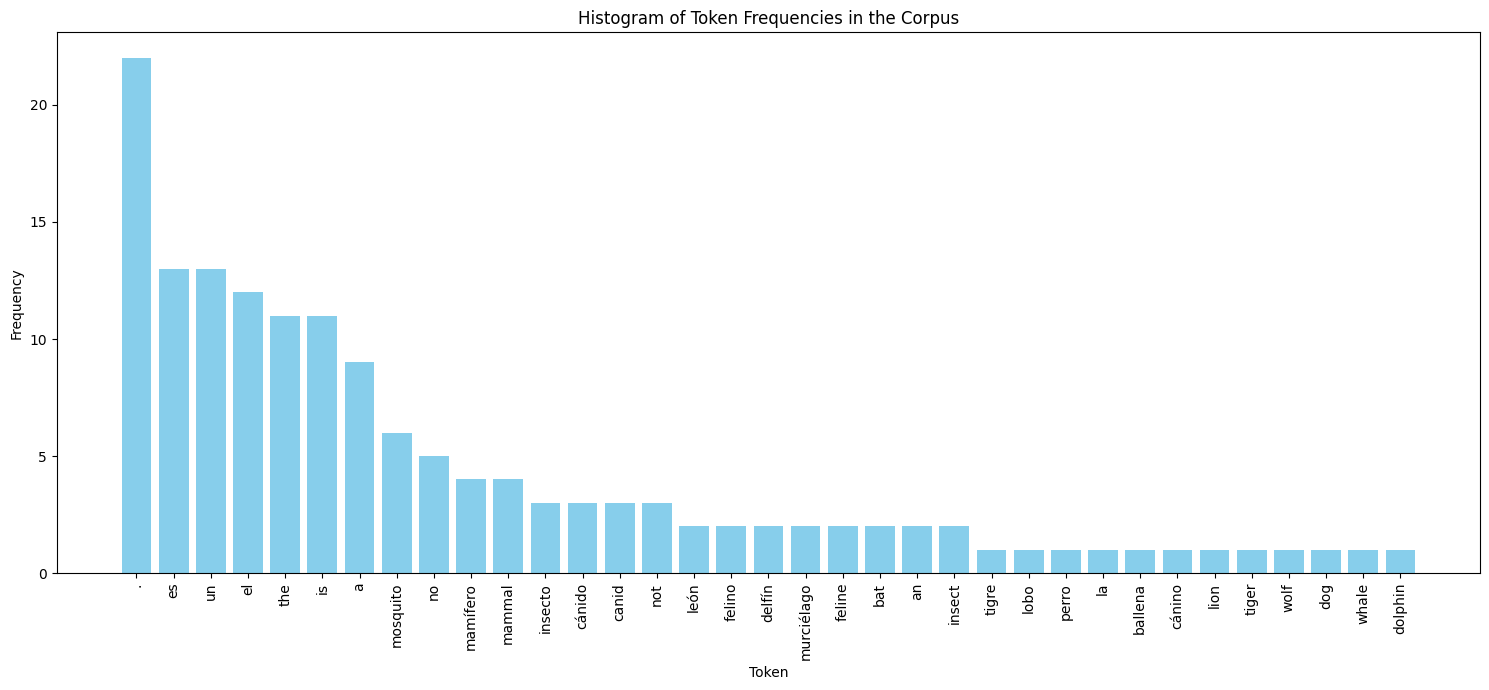

In [78]:
from collections import Counter
import matplotlib.pyplot as plt

# Flatten the list of tokenized sentences into a single list of tokens
all_tokens = [token for sentence_tokens in all_tokenized for token in sentence_tokens]

# Count the frequency of each token
token_counts = Counter(all_tokens)

# Filter out special tokens like <pad> and <mask> if desired for visualization
filtered_token_counts = {token: count for token, count in token_counts.items() if token not in {pad_token, mask_token}}

# Sort tokens by frequency for better visualization
sorted_tokens = sorted(filtered_token_counts.items(), key=lambda item: item[1], reverse=True)

tokens_to_plot = [item[0] for item in sorted_tokens]
counts_to_plot = [item[1] for item in sorted_tokens]

plt.figure(figsize=(15, 7))
plt.bar(tokens_to_plot, counts_to_plot, color='skyblue')
plt.xlabel('Token')
plt.ylabel('Frequency')
plt.title('Histogram of Token Frequencies in the Corpus')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Construcción de ejemplos MLM

En BERT, el aprendizaje no consiste en “predecir el siguiente token”, sino en **predecir el token oculto a partir del contexto completo**.

Aquí construiremos ejemplos muy simples:

- tomamos una frase,
- ocultamos **un token de contenido**,
- la entrada contiene `<mask>`,
- la etiqueta conserva la frase original,
- y la pérdida se aplica **solo** sobre la posición enmascarada.

Para que el ejemplo sea más pedagógico, evitamos enmascarar artículos, verbos funcionales y el punto final.


In [79]:
#non_maskable = {"el", "la", "the", "a", "es", "is", "un", "no", "not", "."}
non_maskable = {"a", "es", "is", "un", "no", "not", "."}

masked_inputs = []
masked_targets = []
masked_positions = []
original_sentences = []

for tokens in all_tokenized:
    for pos, tok in enumerate(tokens):
        if tok in non_maskable:
            continue
        masked = tokens.copy()
        masked[pos] = mask_token
        masked_inputs.append([word_to_id[t] for t in masked])
        masked_targets.append([word_to_id[t] for t in tokens])
        masked_positions.append(pos)
        original_sentences.append(tokens)

print("Número de ejemplos MLM:", len(masked_inputs))
print("Ejemplo enmascarado:")
print("entrada:", [id_to_word[i] for i in masked_inputs[0]])
print("objetivo:", [id_to_word[i] for i in masked_targets[0]])
print("posición enmascarada:", masked_positions[0])


Número de ejemplos MLM: 74
Ejemplo enmascarado:
entrada: ['<mask>', 'león', 'es', 'un', 'felino', '.']
objetivo: ['el', 'león', 'es', 'un', 'felino', '.']
posición enmascarada: 0


In [80]:
max_len = max(len(seq) for seq in masked_inputs)

X = pad_sequences(masked_inputs, maxlen=max_len, padding="post", value=word_to_id[pad_token])
y = pad_sequences(masked_targets, maxlen=max_len, padding="post", value=word_to_id[pad_token])

sample_weights = np.zeros_like(X, dtype="float32")
for i, pos in enumerate(masked_positions):
    sample_weights[i, pos] = 1.0

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Forma de sample_weights:", sample_weights.shape)


Forma de X: (74, 7)
Forma de y: (74, 7)
Forma de sample_weights: (74, 7)


In [92]:
print(X[:25])
print(y[:25])

[[ 1 21 14 34 16  2  0]
 [13  1 14 34 16  2  0]
 [13 21 14 34  1  2  0]
 [ 1 21 28 14 34 18  0]
 [13  1 28 14 34 18  0]
 [13 21 28 14 34  1  0]
 [ 1 33 14 34 16  2  0]
 [13  1 14 34 16  2  0]
 [13 33 14 34  1  2  0]
 [ 1 23 14 34  8  2  0]
 [13  1 14 34  8  2  0]
 [13 23 14 34  1  2  0]
 [ 1 30 14 34  8  2  0]
 [13  1 14 34  8  2  0]
 [13 30 14 34  1  2  0]
 [ 1  5 14 34 25  2  0]
 [20  1 14 34 25  2  0]
 [20  5 14 34  1  2  0]
 [ 1 10 14 34 25  2  0]
 [13  1 14 34 25  2  0]
 [13 10 14 34  1  2  0]
 [ 1 10 28 14 34 18  2]
 [13  1 28 14 34 18  2]
 [13 10 28 14 34  1  2]
 [ 1 27 28 14 34  8  2]]
[[13 21 14 34 16  2  0]
 [13 21 14 34 16  2  0]
 [13 21 14 34 16  2  0]
 [13 21 28 14 34 18  0]
 [13 21 28 14 34 18  0]
 [13 21 28 14 34 18  0]
 [13 33 14 34 16  2  0]
 [13 33 14 34 16  2  0]
 [13 33 14 34 16  2  0]
 [13 23 14 34  8  2  0]
 [13 23 14 34  8  2  0]
 [13 23 14 34  8  2  0]
 [13 30 14 34  8  2  0]
 [13 30 14 34  8  2  0]
 [13 30 14 34  8  2  0]
 [20  5 14 34 25  2  0]
 [20  5 14 34 2

In [82]:
examples_df = pd.DataFrame({
    "entrada": [" ".join(id_to_word[idx] for idx in row if idx != word_to_id[pad_token]) for row in X[:10]],
    "objetivo": [" ".join(id_to_word[idx] for idx in row if idx != word_to_id[pad_token]) for row in y[:10]],
    "posicion_mask": masked_positions[:10],
})
examples_df


,entrada,objetivo,posicion_mask
0,<mask> león es un felino .,el león es un felino .,0
1,el <mask> es un felino .,el león es un felino .,1
2,el león es un <mask> .,el león es un felino .,4
3,<mask> león no es un insecto,el león no es un insecto,0
4,el <mask> no es un insecto,el león no es un insecto,1
5,el león no es un <mask>,el león no es un insecto,5
6,<mask> tigre es un felino .,el tigre es un felino .,0
7,el <mask> es un felino .,el tigre es un felino .,1
8,el tigre es un <mask> .,el tigre es un felino .,4
9,<mask> lobo es un cánido .,el lobo es un cánido .,0


## 5. Capa de embedding de token y posición

Se mantiene la misma idea del notebook anterior: cada token se embebe y se suma con una codificación posicional aprendida.


In [83]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "maxlen": self.maxlen,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config


## 6. Bloque transformer encoder

Conservamos la filosofía del notebook que ya te funciona:

- `LayerNormalization`
- `MultiHeadAttention`
- `Dropout`
- residual
- bloque `Conv1D` como *feed-forward*
- residual final

La diferencia principal respecto al problema autoregresivo anterior es que **ahora no hacemos pooling global**: necesitamos una predicción **por posición** de la secuencia.


In [84]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
    )(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)
    x = Convolution1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Convolution1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res


## 7. Modelo completo tipo MLM

La salida tiene forma:

	size = `(batch, seq_len, vocab_size)`

porque el modelo produce una distribución `softmax` para cada posición.

Durante el entrenamiento, la pérdida se pondera con `sample_weights` para que solo cuente el token enmascarado.


In [85]:
def build_mlm_model(
    input_shape,
    vocab_size,
    embed_dim,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    dropout=0.0,
):
    inputs = Input(shape=input_shape, dtype="int32")
    x = TokenAndPositionEmbedding(input_shape[0], vocab_size, embed_dim)(inputs)

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = LayerNormalization(epsilon=1e-6)(x)
    outputs = Dense(vocab_size, activation="softmax")(x)
    return Model(inputs, outputs)

model = build_mlm_model(
    input_shape=(max_len,),
    vocab_size=len(vocab),
    embed_dim=32,
    head_size=16,
    num_heads=4,
    ff_dim=32,
    num_transformer_blocks=4,
    dropout=0.10,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 7, 32)     │      1,408 │ input_layer_4[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 32)     │         64 │ token_and_positi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 32)     │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_49          │ (None, 7, 32)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 7, 32)     │          0 │ dropout_49[0][0], │
│                     │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 32)     │         64 │ add_32[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_32 (Conv1D)  │ (None, 7, 32)     │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_50          │ (None, 7, 32)     │          0 │ conv1d_32[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_33 (Conv1D)  │ (None, 7, 32)     │      1,056 │ dropout_50[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_33 (Add)        │ (None, 7, 32)     │          0 │ conv1d_33[0][0],  │
│                     │                   │            │ add_32[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 32)     │         64 │ add_33[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 32)     │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 7, 32)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 7, 32)     │          0 │ dropout_52[0][0], │
│                     │                   │            │ add_33[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 7, 32)     │         64 │ add_34[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_34 (Conv1D)  │ (None, 7, 32)     │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 7, 32)     │          0 │ conv1d_34[0][0] 

 Total params: 45,317 (177.02 KB)

 Trainable params: 45,317 (177.02 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenamiento

Como el corpus es diminuto y el objetivo es didáctico, entrenamos bastantes épocas para que el patrón quede bien aprendido.


In [86]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True,
    )
]

history = model.fit(
    X,
    y,
    sample_weight=sample_weights,
    epochs=500,
    batch_size=4,
    verbose=0,
    callbacks=callbacks,
)

print("Épocas entrenadas:", len(history.history["loss"]))
print("Loss final:", history.history["loss"][-1])
print("Accuracy final:", history.history["accuracy"][-1])


Épocas entrenadas: 26
Loss final: 0.1842213124036789
Accuracy final: 0.090733602643013


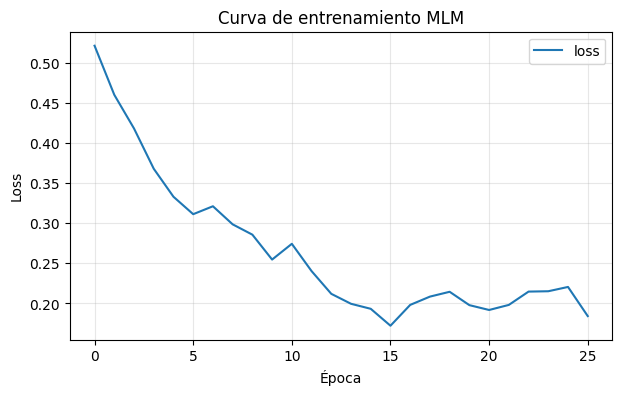

In [87]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de entrenamiento MLM")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 9. Funciones auxiliares de predicción

La función principal recibe una frase con exactamente un `<mask>` y devuelve:

- la posición del token oculto,
- la distribución sobre el vocabulario en esa posición,
- y el ranking de las palabras más probables.


In [88]:
def encode_masked_text(text, word_to_id, max_len):
    tokens = tokenize_text(text)
    if tokens.count(mask_token) != 1:
        raise ValueError("La frase debe contener exactamente un token <mask>.")
    ids = []
    for token in tokens:
        if token not in word_to_id:
            raise ValueError(f"Token desconocido para este vocabulario didáctico: {token!r}")
        ids.append(word_to_id[token])
    padded = pad_sequences([ids], maxlen=max_len, padding="post", value=word_to_id[pad_token])
    mask_pos = tokens.index(mask_token)
    return tokens, padded, mask_pos


def predict_masked_token(model, text, word_to_id, id_to_word, max_len, top_k=8):
    tokens, padded, mask_pos = encode_masked_text(text, word_to_id, max_len)
    probs = model.predict(padded, verbose=0)[0, mask_pos]

    ranked_ids = np.argsort(probs)[::-1]
    ranked_ids = [idx for idx in ranked_ids if id_to_word[idx] not in {pad_token, mask_token}]
    top_ids = ranked_ids[:top_k]

    top_words = [id_to_word[idx] for idx in top_ids]
    top_probs = [float(probs[idx]) for idx in top_ids]
    predicted_word = top_words[0]

    reconstructed = tokens.copy()
    reconstructed[mask_pos] = predicted_word

    return {
        "input_tokens": tokens,
        "mask_position": mask_pos,
        "top_words": top_words,
        "top_probs": top_probs,
        "predicted_word": predicted_word,
        "reconstructed_text": " ".join(reconstructed),
    }


def plot_prediction(result, title_prefix=""):
    plt.figure(figsize=(8, 4))
    plt.bar(result["top_words"], result["top_probs"])
    plt.ylim(0, 1)
    plt.xlabel("Token candidato")
    plt.ylabel("Probabilidad")
    plt.title(
        f"{title_prefix} contexto: '{' '.join(result['input_tokens'])}' | predicción: '{result['predicted_word']}'"
    )
    plt.grid(axis="y", alpha=0.3)
    plt.show()


## 10. Pruebas sobre frases enmascaradas

Primero probamos frases del mismo estilo que el entrenamiento. Después probamos algunas combinaciones útiles para clase.


In [89]:
test_sentences = [
    "el <mask> es un felino .",
    "el lobo es un <mask> .",
    "the <mask> is a mammal .",
    "the dog is a <mask> .",
    #"the dog is not a <mask> .",
    "<mask> dog is a mammal ."
]

results = []
for text in test_sentences:
    result = predict_masked_token(model, text, word_to_id, id_to_word, max_len, top_k=6)
    results.append({
        "frase_enmascarada": text,
        "prediccion": result["predicted_word"],
        "reconstruccion": result["reconstructed_text"],
    })

pd.DataFrame(results)


,frase_enmascarada,prediccion,reconstruccion
0,el <mask> es un felino .,murciélago,el murciélago es un felino .
1,el lobo es un <mask> .,cánido,el lobo es un cánido .
2,the <mask> is a mammal .,dolphin,the dolphin is a mammal .
3,the dog is a <mask> .,canid,the dog is a canid .
4,<mask> dog is a mammal .,the,the dog is a mammal .



Caso 1
Entrada: el <mask> es un felino .
Predicción principal: murciélago
Reconstrucción: el murciélago es un felino .


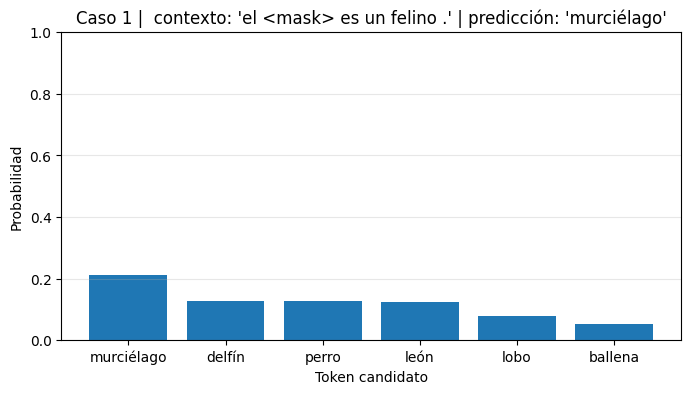


Caso 2
Entrada: el lobo es un <mask> .
Predicción principal: cánido
Reconstrucción: el lobo es un cánido .


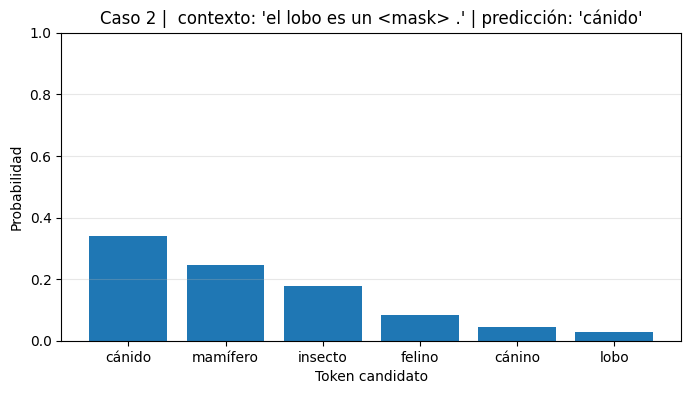


Caso 3
Entrada: the <mask> is a mammal .
Predicción principal: dolphin
Reconstrucción: the dolphin is a mammal .


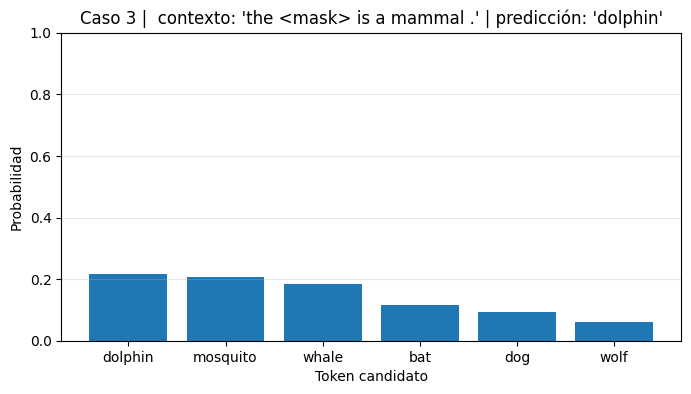


Caso 4
Entrada: the dog is a <mask> .
Predicción principal: canid
Reconstrucción: the dog is a canid .


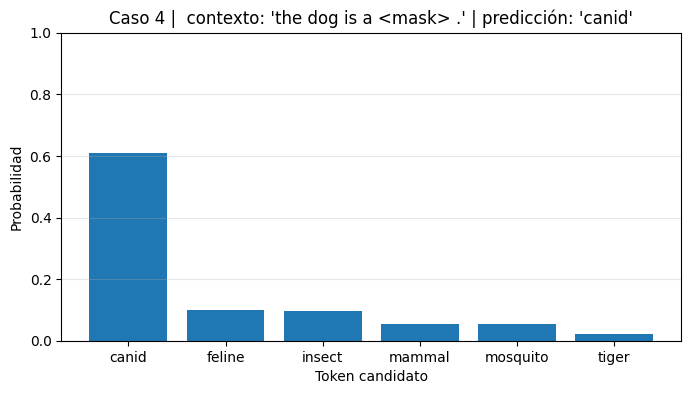


Caso 5
Entrada: <mask> dog is a mammal .
Predicción principal: the
Reconstrucción: the dog is a mammal .


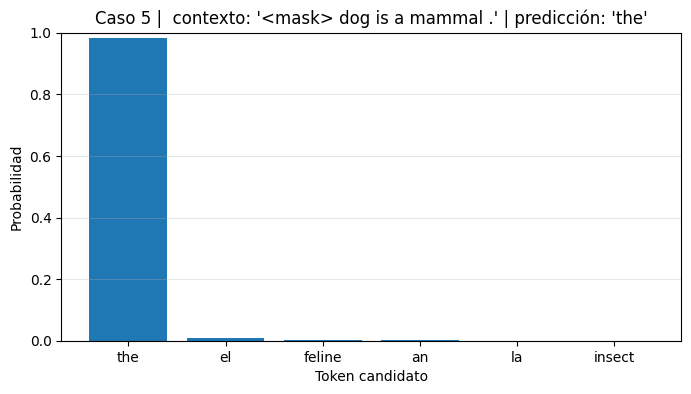

In [90]:
for i, text in enumerate(test_sentences, start=1):
    result = predict_masked_token(model, text, word_to_id, id_to_word, max_len, top_k=6)
    print(f"\nCaso {i}")
    print("Entrada:", text)
    print("Predicción principal:", result["predicted_word"])
    print("Reconstrucción:", result["reconstructed_text"])
    plot_prediction(result, title_prefix=f"Caso {i} | ")


## 11. Comparación conceptual con next-token prediction

### En el notebook anterior

El ejemplo de aprendizaje era:

- entrada: prefijo de la secuencia,
- salida: siguiente token.

Eso corresponde al estilo **autoregresivo** típico de GPT.

### En este notebook

El ejemplo de aprendizaje es:

- entrada: una frase completa pero con un token oculto,
- salida: el token correcto en la posición oculta.

Eso corresponde al estilo **masked language modeling** asociado a BERT.

La diferencia conceptual más importante es que aquí el token oculto puede usar **contexto izquierdo y derecho**.


## 12. Sugerencias para ampliar la práctica

1. **Aumentar el corpus** con más taxonomías:
   - `el aguila es un ave`
   - `the eagle is a bird`
   - `la serpiente es un reptil`
   - `the snake is a reptile`

2. **Separar entrenamiento y prueba** para comprobar mejor la generalización.

3. **Enmascarar diferentes posiciones** y comparar qué tokens son más fáciles o más difíciles.

4. **Comparar MLM frente a next-token prediction** usando exactamente el mismo campo semántico.

## Recomendación pedagógica

Para explicar BERT, la mejor demostración sencilla no es una “traducción no vista”, sino mostrar que el modelo recupera el token oculto usando ambos lados del contexto. Esa es la esencia del pretraining tipo BERT.
